In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine
import warnings # To suppress warings in this notebook,without this,we will get user warnings nose or outdated
warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd().parent
DB_PATH  = BASE_DIR / 'database' / 'olist.db'

engine = create_engine(f'sqlite:///{DB_PATH}')

# Set visual style for all charts in this notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Monthly Revenue Trend 
* mix with 2 axis Bar chart and line plot

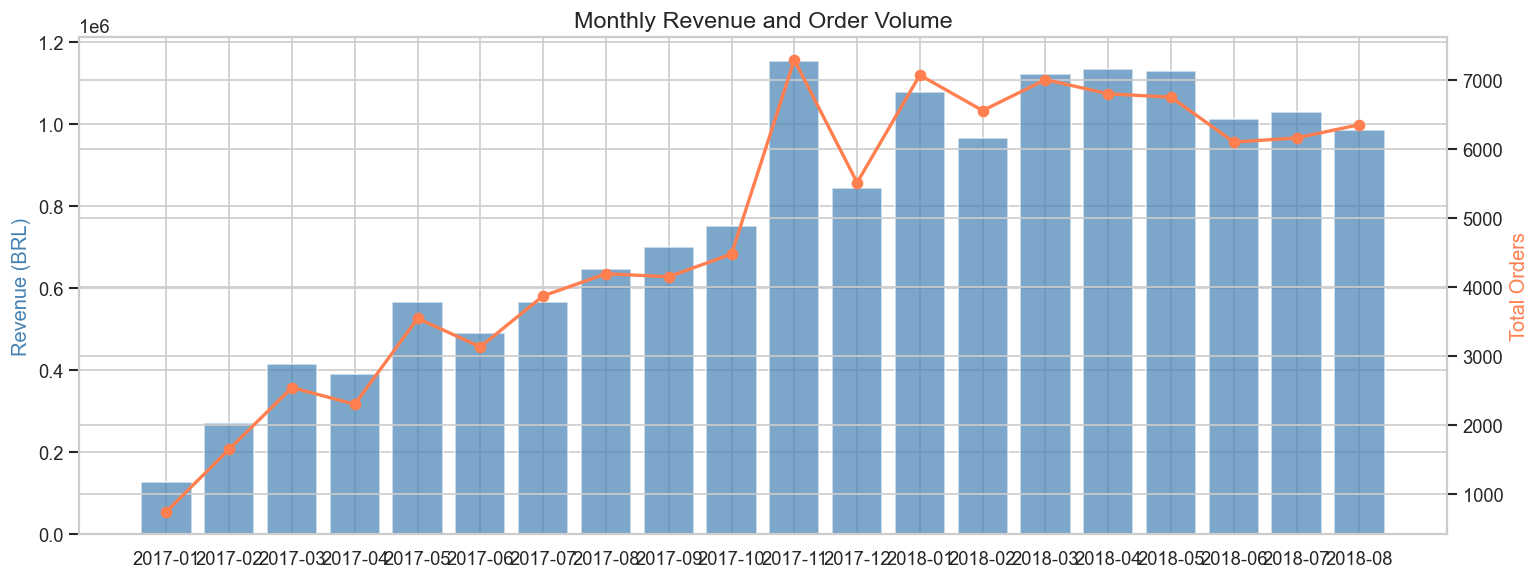

In [ ]:
# Pull data using the same query from notebook 02
# SQL does the aggregation, pandas just receives the clean result
monthly_revenue = pd.read_sql("""
    SELECT
        SUBSTR(o.order_purchase_timestamp, 1, 7) AS month,
        ROUND(SUM(p.payment_value), 2)            AS revenue,
        COUNT(DISTINCT o.order_id)                AS total_orders
    FROM orders o
    JOIN order_payments p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-01-01'
    GROUP BY month
    ORDER BY month
""", engine)

fig, ax1 = plt.subplots(figsize=(13, 5))

# Bar chart for revenue on left y-axis
ax1.bar(monthly_revenue['month'], monthly_revenue['revenue'],
        color='steelblue', alpha=0.7)
ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)# help rotate the x-axis labels to prevent overlap and improve readability

# Line chart for order count on right y-axis
# twinx() creates a second y-axis sharing the same x-axis
# useful when two metrics have very different scales
ax2 = ax1.twinx()
ax2.plot(monthly_revenue['month'], monthly_revenue['total_orders'],
         color='coral', marker='o', linewidth=2)
ax2.set_ylabel('Total Orders', color='coral')

plt.title('Monthly Revenue and Order Volume', fontsize=14)
fig.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'monthly_revenue.png',
            dpi=150, bbox_inches='tight') #bbox_inches='tight' help prevents chart labels from getting cut off when saving.

plt.show()

# Top 10 categories
*Use Horizontal bar chart with ax.barh()

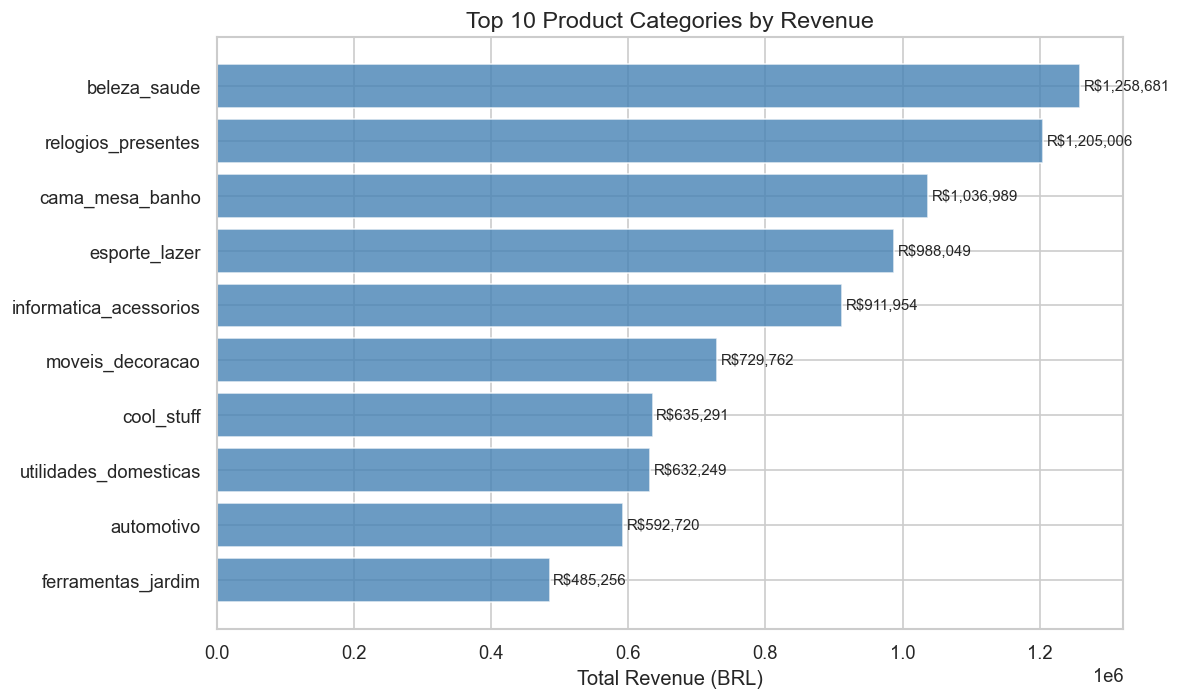

In [53]:
top_categories = pd.read_sql("""
    SELECT
        pr.product_category_name   AS category,
        ROUND(SUM(oi.price), 2)    AS revenue
    FROM order_items oi
    JOIN products pr ON oi.product_id = pr.product_id
    WHERE pr.product_category_name IS NOT NULL
    GROUP BY category
    ORDER BY revenue DESC
    LIMIT 10
""", engine)

fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart — better than vertical when category names are long
# [::-1] reverses the order so highest revenue appears at the top
ax.barh(top_categories['category'][::-1],
        top_categories['revenue'][::-1],
        color='steelblue', alpha=0.8)

ax.set_xlabel('Total Revenue (BRL)')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14)

# Add value labels at the end of each bar
for i, (rev, cat) in enumerate(zip(top_categories['revenue'][::-1],
                                    top_categories['category'][::-1])):
    ax.text(rev + 5000, i, f'R${rev:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'top_categories.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Review score distribution
* use bar chart but add percentage label with count/total *100
* use bar'x position and width to center the label throught ax.text()


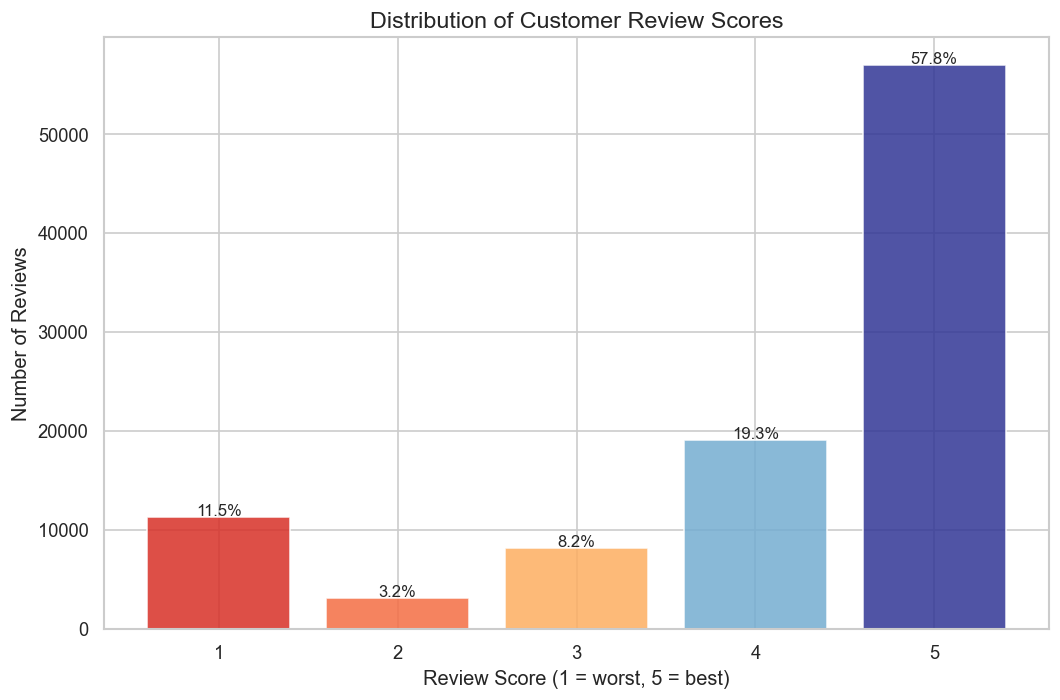

In [54]:
review_dist = pd.read_sql("""
    SELECT review_score, COUNT(*) AS count
    FROM order_reviews
    GROUP BY review_score
    ORDER BY review_score
""", engine)

fig, ax = plt.subplots(figsize=(9, 6))

# Colour each bar differently to show sentiment visually
# red = bad score, blue = good score
colors = ['#d73027', '#f46d43', '#fdae61', '#74add1', '#313695']
bars = ax.bar(review_dist['review_score'].astype(str),
              review_dist['count'],
              color=colors, alpha=0.85)

# Add percentage label on top of each bar
total = review_dist['count'].sum()
for bar, count in zip(bars, review_dist['count']):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,# use bar'x position and width to center the label ,bar.get_x()
            bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', fontsize=10)

ax.set_xlabel('Review Score (1 = worst, 5 = best)')
ax.set_ylabel('Number of Reviews')
ax.set_title('Distribution of Customer Review Scores', fontsize=14)
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'review_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Delivery days distribution with Histogram(Distribution);Box plot also Distribution
* Use ax.hist()
* Use actual_delivery_days BETWEEN 0 AND 60
* Defien median with df[colunm].median to get the median value for distribution of column
* then use a ax.axvline(vertical line) to show the median value with color,linestyele,linewidth and also a label say what is that

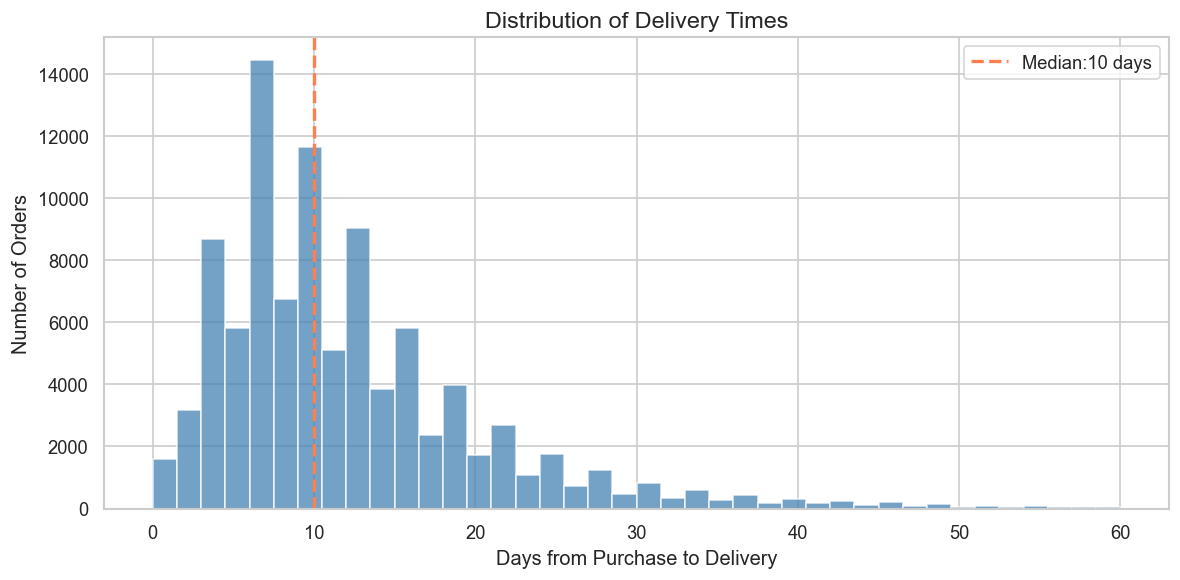

In [55]:
# Use orders_clean which has actual_delivery_days already calculated
delivery_days = pd.read_sql("""
    SELECT actual_delivery_days
    FROM orders_clean
    WHERE actual_delivery_days IS NOT NULL
      AND actual_delivery_days BETWEEN 0 AND 60
""", engine)
# BETWEEN 0 AND 60 removes extreme outliers like that 209-day delivery
# outliers would compress the chart making normal values unreadable

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(delivery_days['actual_delivery_days'],
        bins=40, color='steelblue', alpha=0.75, edgecolor='white')

# Add median line — median is more meaningful than mean for skewed distributions
median_val = delivery_days['actual_delivery_days'].median()
ax.axvline(median_val, color='coral', linestyle='--', linewidth=2,
           label=f'Median:{median_val:.0f} days')

ax.set_xlabel('Days from Purchase to Delivery')
ax.set_ylabel('Number of Orders')
ax.set_title('Distribution of Delivery Times', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'delivery_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()